# Week 2 - Seminar - Exploratory Data Analysis and Plotting


In [49]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# This prevents pandas from showing weird warnings
pd.options.mode.chained_assignment = None

db_path = "data.duckdb"
schema = "data.attendance"

conn = duckdb.connect()
conn.execute(f"ATTACH '{db_path}' AS data (READ_ONLY)")
conn.execute(f"USE {schema}");


## Agenda

Repeat 10 times:
1. I show you the task
2. You work on it for 3-5 minutes
3. I show you my solution
4. You compare my solution to yours and raise questions, we discuss for several minutes.


## Data Preprocessing

In [ ]:
df = conn.sql(
    """
    WITH attendance AS (
        SELECT
            report_period,
            school_code,
            student_class,
            subject_code,
            electronic_diary,
            FIRST(student_count_diary) student_count_diary,
            SUM(excused_lessons_illness) excused_lessons_illness,
            SUM(excused_lessons_other) excused_lessons_other,
            SUM(unexcused_lessons) unexcused_lessons
        FROM attendance
        WHERE division_code IS NULL
        GROUP BY all
    ),
        school AS (
        SELECT 
            school_code, 
            school_name, 
            municipality_name
        FROM school
        WHERE division_code IS NULL
    ),
        subject AS (
        SELECT
            electronic_diary,
            subject_code,
            subject_name_en,
        FROM subject
    )
    SELECT
        school.school_name,
        school.school_code,
        school.municipality_name,
        attendance.student_class,
        attendance.report_period,
        subject.subject_name_en,
        FIRST(attendance.student_count_diary) AS student_count,
        SUM(attendance.excused_lessons_illness) AS excused_lessons_illness,
        SUM(attendance.excused_lessons_other) AS excused_lessons_other,
        SUM(attendance.unexcused_lessons) AS unexcused_lessons
    FROM attendance
    JOIN school ON attendance.school_code = school.school_code
    JOIN subject ON attendance.subject_code = subject.subject_code
        AND attendance.electronic_diary = subject.electronic_diary
    GROUP BY all
"""
).df()

In [51]:
df = df[(df["subject_name_en"] == "Mathematics") & (df["student_class"] == 12)]

In [52]:
# Filter on report period
df = df[df["report_period"].between("2018-09-01", "2024-05-31")]
# Get rid of summer months
df["month"] = df["report_period"].dt.month
df = df[~df["month"].isin([6, 7, 8])]

# Make sure the set of schools is the same across the years
# First, count how many report periods each school has
schools = df.groupby("school_name").agg(
    report_period_count=("report_period", "nunique")
)
# Then, filter on the schools that have data for all 6 school years (9 months each year)
schools = schools[schools["report_period_count"] == 6 * 9]
df = df[df["school_name"].isin(schools.index)]

df["school_year"] = df["report_period"].dt.year - (
    df["report_period"].dt.month <= 5
).astype(int)
df[["report_period", "school_year"]].sample(5)

df["excused_illness_per_student"] = df["excused_lessons_illness"] / df["student_count"]
df["excused_other_per_student"] = df["excused_lessons_other"] / df["student_count"]
df["unexcused_per_student"] = df["unexcused_lessons"] / df["student_count"]
df["total_missed"] = (
    df["excused_lessons_illness"]
    + df["excused_lessons_other"]
    + df["unexcused_lessons"]
)
df["total_missed_per_student"] = df["total_missed"] / df["student_count"]
df["report_period"] = df["report_period"].dt.date

df.sample(5)

,school_name,school_code,municipality_name,student_class,report_period,subject_name_en,student_count,excused_lessons_illness,excused_lessons_other,unexcused_lessons,month,school_year,excused_illness_per_student,excused_other_per_student,unexcused_per_student,total_missed,total_missed_per_student
3842889,Vilniaus Juzefo Ignacijaus Kraševskio gimnazija,190007878,Vilniaus m. sav.,12,2019-05-01,Mathematics,48,29.0,30.0,0.0,5,2018,0.604167,0.625000,0.000000,59.0,1.229167
3876242,Šalčininkų r. Baltosios Vokės „Šilo“ gimnazija,191415562,Šalčininkų r. sav.,12,2023-10-01,Mathematics,14,24.0,0.0,0.0,10,2023,1.714286,0.000000,0.000000,24.0,1.714286
619055,Pakruojo „Atžalyno“ gimnazija,190066410,Pakruojo r. sav.,12,2023-02-01,Mathematics,79,40.0,7.0,33.0,2,2022,0.506329,0.088608,0.417722,80.0,1.012658
2227439,Vilniaus šv. Kristoforo gimnazija,302420721,Vilniaus m. sav.,12,2018-10-01,Mathematics,115,136.0,18.0,105.0,10,2018,1.182609,0.156522,0.913043,259.0,2.252174
1153404,Kelmės rajono Užvenčio Šatrijos Raganos gimnazija,190092914,Kelmės r. sav.,12,2020-02-01,Mathematics,13,13.0,8.0,0.0,2,2019,1.000000,0.615385,0.000000,21.0,1.615385


## Tasks

### Task 1

Show how average `total_missed_per_student` changes across time. The plot should be titled, and axes should be labelled clearly. 


### Task 2

Show how average `total_missed_per_student` changes across time for these municipalities:

* Vilniaus m. sav.
* Vilniaus r. sav.
* Kauno m. sav.
* Kauno r. sav.

The lines should have no errorbar. 


### Task 3

There's something going on in the Vilnius region in school year 2023. Only for that municipality and school year, plot `total_missed_per_student` across time *by school*.

The plot should be titled and labelled clearly.


### Task 4

The plot above is not very nice to look at. Let's make it into a table.

Each row of the table should represent one school. Each column should be one report period. Only show data from 2023-09 to 2023-12. Apply conditional formatting on the *rows* of the table. The numbers in the table should be rounded to two significant digits.

Hint - you will have to pivot the table.


### Task 5

What's causing a spike in total missed lessons on 2023-11 - unexcused missed lessons, illness, or "other"? Make a visualization that answers this question.


### Task 6

For the four municipalities mentioned above and for the report period of 2024-05-01, create a scatter plot with `excused_illness_per_student` on the y axis and `excused_other_per_student` on the x axis. Indicate which municipality the point on the plot belongs to.

The plot should be titled and labelled clearly.


### Task 7

Plot the distribution of `total_missed_per_student` on a kdeplot for school year 2020, months September, February and May. Different months should have different curves.

The plot should be titled and labelled clearly.



### Task 8

So far we've been making single plots. How can we create multiple plots on a single canvas?

Plot the same plot as above, but for both `excused_other_per_student` and `excused_illness_per_student` on separate plots, but on the same canvas.

All plots should be titled and labelled clearly.


<Axes: xlabel='report_period', ylabel='excused_other_per_student'>

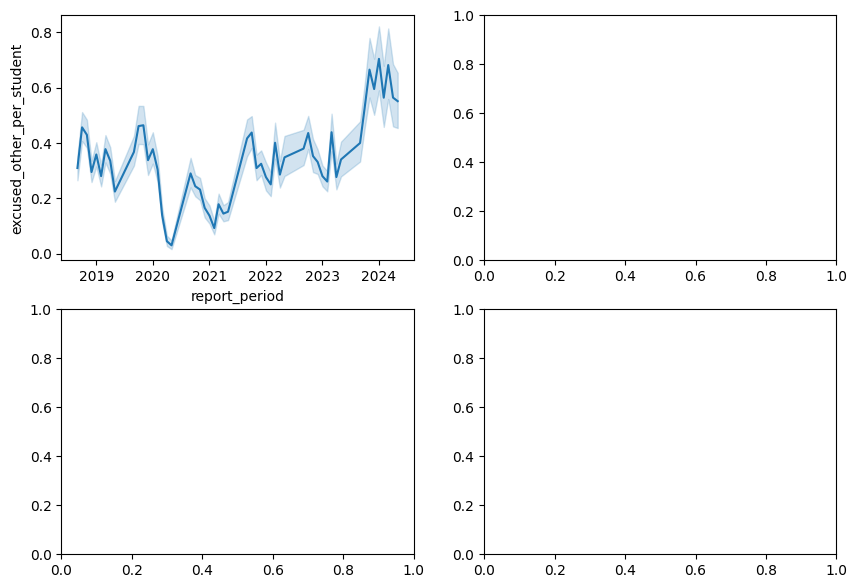

In [59]:
# Hint
fig, axs = plt.subplots(2, 2, figsize=(10, 7))
sns.lineplot(data=df, x="report_period", y="excused_other_per_student", ax=axs[0][0])


### Task 9

Now plot all three metrics on different plots, but still the same canvas. Don't repeat yourself! (use a for loop)

```

```

In [44]:
# Hint
columns = [...]
fig, axs = plt.subplots(1, 3, figsize=(..., ...))
for column, ax in zip(columns, axs):
    pass

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

### Task 10

One last table - show the number of schools, and then average, median and 90th percentile of `total_missed_per_student` by *municipality*, for the whole period (you don't need to apply any filters). 

Display top 20 schools by school count. Apply conditional formatting on the table such that outliers in each column stand out. Do not apply conditional formatting on the school count column.


In [46]:
# hint - do this in the aggregation step
("total_missed_per_student", lambda x: x.quantile(0.8))


('total_missed_per_student', <function __main__.<lambda>(x)>)